# **Müşteri Kayıp Analizi ve Tahminleme Modeli (Churn Prediction)**

Bu notebook, şirket verilerini kullanarak müşteri kaybını tahmin edecek ve her müşteri için churn skorları üretecektir.

### **1. Kütüphaneler ve Ayarlar**

In [13]:
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
)

from sklearn.calibration import calibration_curve

pl.Config.set_fmt_float("full")
pl.Config.set_tbl_cols(30)

RANDOM_STATE = 42

### **2. Verilerin Okunması ve Hazırlanması**

In [14]:
DATA_DIR = Path(
    r"C:\Users\kerem\Desktop\capsstone\data"
)

CACHE_DIR = DATA_DIR / "model_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SPENDING_CACHE = (
    CACHE_DIR / "customer_spending.parquet"
)

COMPLAINT_CACHE = (
    CACHE_DIR / "customer_complaints_features.parquet"
)

CUSTOMER_CACHE = (
    CACHE_DIR / "customer.parquet"
)

# **Model tablolarını LazyFrame olarak açma**

In [15]:
def month_to_index(year_month: str) -> int:
    year = int(year_month[:4])
    month = int(year_month[4:])

    return year * 12 + month

In [16]:
spending_lf = (
    pl.scan_parquet(SPENDING_CACHE)
    .with_columns(
        (
            pl.col("billing_year_month")
            .str.slice(0, 4)
            .cast(pl.Int32) * 12
            +
            pl.col("billing_year_month")
            .str.slice(4, 2)
            .cast(pl.Int32)
        ).alias("month_index")
    )
)

complaints_lf = (
    pl.scan_parquet(COMPLAINT_CACHE)
    .with_columns(
        (
            pl.col("billing_year_month")
            .str.slice(0, 4)
            .cast(pl.Int32) * 12
            +
            pl.col("billing_year_month")
            .str.slice(4, 2)
            .cast(pl.Int32)
        ).alias("month_index")
    )
)

customers_lf = pl.scan_parquet(
    CUSTOMER_CACHE
)

# **Churn tanımı**

**Bir müşteri snapshot ayında aktifse ve sonraki üç ayın hiçbirinde ödeme kaydı bulunmuyorsa churn etiketi 1 olur. Model yalnız snapshot ve geçmiş altı aylık bilgileri kullanır. Gelecek dönem bilgileri feature olarak kullanılmaz.**

In [17]:
OBSERVATION_MONTHS = 6
CHURN_HORIZON_MONTHS = 3

**Transaction Matrix**

In [40]:
SNAPSHOT_MONTH = "202509"
snapshot_index = month_to_index(SNAPSHOT_MONTH)

sample_customer_ids = (
    spending_lf
    .filter(
        pl.col("billing_year_month")
        == SNAPSHOT_MONTH
    )
    .select("customer_id")
    .unique()
    .sort("customer_id")
    .head(1000)
    .collect()
    .get_column("customer_id")
    .to_list()
)

# Yalnızca son 12 ayı gösteriyoruz.
transaction_matrix_sample = (
    spending_lf
    .filter(
        pl.col("customer_id").is_in(
            sample_customer_ids
        )
        & pl.col("month_index").is_between(
            snapshot_index - 11,
            snapshot_index,
        )
    )
    .select(
        "customer_id",
        "billing_year_month",
        "bill_amount",
    )
    .collect()
    .pivot(
        on="billing_year_month",
        index="customer_id",
        values="bill_amount",
        aggregate_function="sum",
    )
    .fill_null(0)
    .sort("customer_id")
)

month_columns = sorted(
    column
    for column in transaction_matrix_sample.columns
    if column != "customer_id"
)

transaction_matrix_sample = (
    transaction_matrix_sample
    .select(
        "customer_id",
        *month_columns,
    )
)

transaction_matrix_pd = pd.DataFrame(
    transaction_matrix_sample.to_dicts()
).set_index("customer_id")

display(
    transaction_matrix_pd.style
    .format("{:.2f}")
    .background_gradient(
        cmap="Blues",
        axis=None,
    )
)

**Aktif–pasif transition matrix**

In [41]:
activity_lf = (
    spending_lf
    .select(
        "customer_id",
        "month_index",
    )
    .unique()
)

monthly_active_lf = (
    activity_lf
    .group_by("month_index")
    .agg(
        pl.col("customer_id")
        .n_unique()
        .alias("active_now")
    )
)

monthly_next_lf = (
    monthly_active_lf
    .select(
        (
            pl.col("month_index") - 1
        ).alias("month_index"),

        pl.col("active_now")
        .alias("active_next"),
    )
)

future_activity_lf = (
    activity_lf
    .select(
        "customer_id",
        (
            pl.col("month_index") - 1
        ).alias("month_index"),
    )
)

active_to_active_lf = (
    activity_lf
    .join(
        future_activity_lf,
        on=["customer_id", "month_index"],
        how="inner",
    )
    .group_by("month_index")
    .agg(
        pl.col("customer_id")
        .n_unique()
        .alias("active_to_active")
    )
)

total_customers = (
    customers_lf
    .select(
        pl.col("customer_id").n_unique()
    )
    .collect()
    .item()
)

transition_by_month = (
    monthly_active_lf
    .join(
        monthly_next_lf,
        on="month_index",
        how="inner",
    )
    .join(
        active_to_active_lf,
        on="month_index",
        how="left",
    )
    .with_columns(
        pl.col("active_to_active").fill_null(0)
    )
    .with_columns(
        (
            pl.col("active_now")
            - pl.col("active_to_active")
        ).alias("active_to_inactive"),

        (
            pl.col("active_next")
            - pl.col("active_to_active")
        ).alias("inactive_to_active"),

        (
            total_customers
            - pl.col("active_now")
            - pl.col("active_next")
            + pl.col("active_to_active")
        ).alias("inactive_to_inactive"),
    )
    .select(
        pl.col("active_to_active").sum(),
        pl.col("active_to_inactive").sum(),
        pl.col("inactive_to_active").sum(),
        pl.col("inactive_to_inactive").sum(),
    )
    .collect()
    .row(0, named=True)
)

transition_counts = np.array([
    [
        transition_by_month["active_to_active"],
        transition_by_month["active_to_inactive"],
    ],
    [
        transition_by_month["inactive_to_active"],
        transition_by_month["inactive_to_inactive"],
    ],
], dtype=float)

transition_probabilities = (
    transition_counts
    / transition_counts.sum(
        axis=1,
        keepdims=True,
    )
)

transition_matrix = pd.DataFrame(
    transition_probabilities,
    index=["Şu an aktif", "Şu an pasif"],
    columns=["Sonraki ay aktif", "Sonraki ay pasif"],
)

display(transition_matrix)

,Sonraki ay aktif,Sonraki ay pasif
Şu an aktif,0.960511,0.039489
Şu an pasif,0.016397,0.983603


**Snapshot feature üretme fonksiyonu**

In [19]:
def build_churn_snapshot(
    snapshot_month: str,
    include_label: bool = True,
) -> pl.DataFrame:
    snapshot_index = month_to_index(
        snapshot_month
    )

    observation_start = (
        snapshot_index
        - OBSERVATION_MONTHS
        + 1
    )

    snapshot_year = int(
        snapshot_month[:4]
    )

    # Snapshot ayında aktif olan müşteriler
    eligible_lf = (
        spending_lf
        .filter(
            pl.col("month_index")
            == snapshot_index
        )
        .group_by("customer_id")
        .agg(
            pl.col("bill_amount")
            .last()
            .alias("current_bill"),

            pl.col("data_usage")
            .last()
            .alias("current_data_usage"),
        )
    )

    # Son altı aylık finansal davranış
    spending_features_lf = (
        spending_lf
        .filter(
            pl.col("month_index").is_between(
                observation_start,
                snapshot_index,
            )
        )
        .group_by("customer_id")
        .agg(
            pl.col("bill_amount")
            .mean()
            .alias("bill_mean_6m"),

            pl.col("bill_amount")
            .std()
            .alias("bill_std_6m"),

            pl.col("bill_amount")
            .filter(
                pl.col("month_index")
                >= snapshot_index - 2
            )
            .mean()
            .alias("bill_mean_3m"),

            pl.col("data_usage")
            .mean()
            .alias("usage_mean_6m"),

            pl.col("data_usage")
            .std()
            .alias("usage_std_6m"),

            pl.col("data_usage")
            .filter(
                pl.col("month_index")
                >= snapshot_index - 2
            )
            .mean()
            .alias("usage_mean_3m"),

            pl.col("bill_amount")
            .filter(
                pl.col("month_index")
                == snapshot_index - 1
            )
            .first()
            .alias("previous_bill"),

            pl.col("data_usage")
            .filter(
                pl.col("month_index")
                == snapshot_index - 1
            )
            .first()
            .alias("previous_data_usage"),

            pl.col("month_index")
            .n_unique()
            .alias("active_months_6m"),
        )
    )

    # Geçmiş şikâyet davranışı
    complaint_features_lf = (
        complaints_lf
        .filter(
            pl.col("month_index").is_between(
                observation_start,
                snapshot_index,
            )
        )
        .group_by("customer_id")
        .agg(
            pl.len()
            .alias("complaint_count_6m"),

            pl.col("billing_year_month")
            .filter(
                pl.col("month_index")
                >= snapshot_index - 2
            )
            .count()
            .alias("complaint_count_3m"),

            pl.col("problem_category")
            .n_unique()
            .alias("unique_problem_categories_6m"),

            pl.col("chat_message_count")
            .sum()
            .alias("chat_message_count_6m"),
        )
    )

    snapshot_lf = (
        eligible_lf
        .join(
            spending_features_lf,
            on="customer_id",
            how="left",
        )
        .join(
            complaint_features_lf,
            on="customer_id",
            how="left",
        )
        .join(
            customers_lf,
            on="customer_id",
            how="left",
        )
        .with_columns(
            pl.col(
                "complaint_count_6m",
                "complaint_count_3m",
                "unique_problem_categories_6m",
                "chat_message_count_6m",
            ).fill_null(0),

            (
                OBSERVATION_MONTHS
                - pl.col("active_months_6m")
            ).alias("inactive_months_6m"),

            (
                pl.col("current_bill")
                - pl.col("previous_bill")
            ).alias("bill_change_1m"),

            (
                pl.col("current_data_usage")
                - pl.col("previous_data_usage")
            ).alias("usage_change_1m"),

            (
                snapshot_year
                - pl.col("birth_year")
            ).alias("age"),

            pl.lit(snapshot_month)
            .alias("snapshot_month"),
        )
    )

    if include_label:
        future_activity_lf = (
            spending_lf
            .filter(
                pl.col("month_index").is_between(
                    snapshot_index + 1,
                    snapshot_index
                    + CHURN_HORIZON_MONTHS,
                )
            )
            .group_by("customer_id")
            .agg(
                pl.col("month_index")
                .n_unique()
                .alias("future_active_months")
            )
        )

        snapshot_lf = (
            snapshot_lf
            .join(
                future_activity_lf,
                on="customer_id",
                how="left",
            )
            .with_columns(
                pl.col("future_active_months")
                .fill_null(0)
            )
            .with_columns(
                (
                    pl.col("future_active_months")
                    == 0
                )
                .cast(pl.Int8)
                .alias("churn")
            )
            .drop("future_active_months")
        )

    return snapshot_lf.collect(
        engine="streaming"
    )

**Zaman bazlı train, validation ve test**

In [20]:
TRAIN_SNAPSHOTS = [
    "202312",
    "202403",
    "202406",
]

VALIDATION_SNAPSHOT = "202412"
TEST_SNAPSHOT = "202509"

In [21]:
train_frames = []

for snapshot in TRAIN_SNAPSHOTS:
    print(f"Train snapshot hazırlanıyor: {snapshot}")

    train_frames.append(
        build_churn_snapshot(snapshot)
    )

train_df = pl.concat(
    train_frames,
    how="vertical_relaxed",
)

validation_df = build_churn_snapshot(
    VALIDATION_SNAPSHOT
)

test_df = build_churn_snapshot(
    TEST_SNAPSHOT
)

Train snapshot hazırlanıyor: 202312
Train snapshot hazırlanıyor: 202403
Train snapshot hazırlanıyor: 202406


In [22]:
split_summary = pl.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],
    "row_count": [
        train_df.height,
        validation_df.height,
        test_df.height,
    ],
    "churn_count": [
        train_df["churn"].sum(),
        validation_df["churn"].sum(),
        test_df["churn"].sum(),
    ],
    "churn_rate": [
        train_df["churn"].mean(),
        validation_df["churn"].mean(),
        test_df["churn"].mean(),
    ],
})

display(split_summary)

split,row_count,churn_count,churn_rate
str,i64,i64,f64
"""train""",367459,14016,0.03814303092317783
"""validation""",96635,3676,0.03804004760180059
"""test""",81204,3079,0.0379168513866312


**Precision@K, Recall@K ve Lift@K**

In [23]:
def ranking_metrics(
    y_true,
    y_score,
    customer_value=None,
    k_values=(0.01, 0.05, 0.10, 0.20),
):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    order = np.argsort(-y_score)

    prevalence = y_true.mean()
    total_positive = y_true.sum()

    if customer_value is not None:
        customer_value = np.asarray(
            customer_value
        )

        total_churn_value = (
            customer_value[y_true == 1]
            .sum()
        )

    rows = []

    for k_fraction in k_values:
        selected_count = max(
            1,
            int(
                np.ceil(
                    len(y_true) * k_fraction
                )
            ),
        )

        selected_indices = order[
            :selected_count
        ]

        selected_true = y_true[
            selected_indices
        ]

        true_positive_count = (
            selected_true.sum()
        )

        precision_at_k = (
            true_positive_count
            / selected_count
        )

        recall_at_k = (
            true_positive_count
            / total_positive
            if total_positive > 0
            else 0
        )

        lift_at_k = (
            precision_at_k / prevalence
            if prevalence > 0
            else 0
        )

        row = {
            "k_percent": int(
                k_fraction * 100
            ),
            "selected_customer_count": (
                selected_count
            ),
            "true_churn_count": int(
                true_positive_count
            ),
            "precision_at_k": (
                precision_at_k
            ),
            "recall_at_k": recall_at_k,
            "gain_at_k": recall_at_k,
            "lift_at_k": lift_at_k,
        }

        if customer_value is not None:
            selected_churn_value = (
                customer_value[
                    selected_indices
                ]
                * selected_true
            ).sum()

            row["revenue_capture_at_k"] = (
                selected_churn_value
                / total_churn_value
                if total_churn_value > 0
                else 0
            )

        rows.append(row)

    return pd.DataFrame(rows)

**Genel rare-event metrikleri**

In [24]:
def probability_metrics(
    y_true,
    y_score,
):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    clipped_score = np.clip(
        y_score,
        1e-6,
        1 - 1e-6,
    )

    return {
        "prevalence": y_true.mean(),
        "pr_auc_average_precision": (
            average_precision_score(
                y_true,
                y_score,
            )
        ),
        "roc_auc_secondary": (
            roc_auc_score(
                y_true,
                y_score,
            )
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_score,
        ),
        "log_loss": log_loss(
            y_true,
            clipped_score,
        ),
    }

**Model Feature Listesi**

In [25]:
NUMERIC_FEATURES = [
    "current_bill",
    "current_data_usage",
    "previous_bill",
    "previous_data_usage",
    "bill_mean_3m",
    "bill_mean_6m",
    "bill_std_6m",
    "usage_mean_3m",
    "usage_mean_6m",
    "usage_std_6m",
    "active_months_6m",
    "inactive_months_6m",
    "bill_change_1m",
    "usage_change_1m",
    "complaint_count_3m",
    "complaint_count_6m",
    "unique_problem_categories_6m",
    "chat_message_count_6m",
    "age",
]

CATEGORICAL_FEATURES = [
    "city",
]

FEATURES = (
    NUMERIC_FEATURES
    + CATEGORICAL_FEATURES
)

In [26]:
def to_sklearn_data(frame):
    X = pd.DataFrame(
        frame
        .select(FEATURES)
        .to_dict(as_series=False)
    )

    y = frame[
        "churn"
    ].to_numpy()

    value = frame[
        "current_bill"
    ].to_numpy()

    return X, y, value

In [27]:
X_train, y_train, train_value = (
    to_sklearn_data(train_df)
)

X_validation, y_validation, validation_value = (
    to_sklearn_data(validation_df)
)

X_test, y_test, test_value = (
    to_sklearn_data(test_df)
)

**Random ranking baseline**

In [28]:
random_results = []

for seed in range(50):
    rng = np.random.default_rng(seed)

    random_scores = rng.random(
        len(y_test)
    )

    result = ranking_metrics(
        y_test,
        random_scores,
        customer_value=test_value,
    )

    result["seed"] = seed
    random_results.append(result)

random_baseline = (
    pd.concat(
        random_results,
        ignore_index=True,
    )
    .groupby("k_percent")
    .mean(numeric_only=True)
    .reset_index()
)

display(random_baseline)

,k_percent,selected_customer_count,true_churn_count,precision_at_k,recall_at_k,gain_at_k,lift_at_k,revenue_capture_at_k,seed
0,1,813.0,29.64,0.036458,0.009627,0.009627,0.961514,0.009461,24.5
1,5,4061.0,154.20,0.037971,0.050081,0.050081,1.001427,0.049725,24.5
2,10,8121.0,309.56,0.038118,0.100539,0.100539,1.005317,0.100674,24.5
3,20,16241.0,617.62,0.038028,0.200591,0.200591,1.002943,0.200119,24.5


**Logistic Regression baseline**

In [29]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median"),
    ),
    (
        "scaler",
        StandardScaler(),
    ),
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        ),
    ),
    (
        "one_hot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
        ),
    ),
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        NUMERIC_FEATURES,
    ),
    (
        "categorical",
        categorical_pipeline,
        CATEGORICAL_FEATURES,
    ),
])

In [30]:
def create_logistic_model(
    class_weight=None,
):
    return Pipeline([
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                class_weight=class_weight,
                max_iter=500,
                solver="lbfgs",
                random_state=RANDOM_STATE,
            ),
        ),
    ])

In [31]:
candidate_models = {
    "logistic_unweighted": (
        create_logistic_model(
            class_weight=None
        )
    ),
    "logistic_balanced": (
        create_logistic_model(
            class_weight="balanced"
        )
    ),
}

validation_results = []
trained_models = {}

for model_name, model in candidate_models.items():
    print(f"Eğitiliyor: {model_name}")

    model.fit(
        X_train,
        y_train,
    )

    validation_scores = (
        model.predict_proba(
            X_validation
        )[:, 1]
    )

    overall = probability_metrics(
        y_validation,
        validation_scores,
    )

    topk = ranking_metrics(
        y_validation,
        validation_scores,
        customer_value=validation_value,
    )

    lift_at_5 = (
        topk.loc[
            topk["k_percent"] == 5,
            "lift_at_k",
        ]
        .iloc[0]
    )

    precision_at_5 = (
        topk.loc[
            topk["k_percent"] == 5,
            "precision_at_k",
        ]
        .iloc[0]
    )

    validation_results.append({
        "model": model_name,
        **overall,
        "precision_at_5_percent": (
            precision_at_5
        ),
        "lift_at_5_percent": lift_at_5,
    })

    trained_models[model_name] = model

validation_comparison = (
    pd.DataFrame(validation_results)
    .sort_values(
        "lift_at_5_percent",
        ascending=False,
    )
)

display(validation_comparison)

Eğitiliyor: logistic_unweighted
Eğitiliyor: logistic_balanced


,model,prevalence,pr_auc_average_precision,roc_auc_secondary,brier_score,log_loss,precision_at_5_percent,lift_at_5_percent
1,logistic_balanced,0.03804,0.082443,0.684465,0.220973,0.640575,0.114652,3.013990
0,logistic_unweighted,0.03804,0.082350,0.684139,0.036005,0.154070,0.113204,2.975907


**En iyi baseline modelini test etme**

In [32]:
best_model_name = (
    validation_comparison
    .iloc[0]["model"]
)

best_class_weight = (
    "balanced"
    if best_model_name
    == "logistic_balanced"
    else None
)

print(
    f"Seçilen baseline: {best_model_name}"
)

Seçilen baseline: logistic_balanced


In [33]:
X_train_final = pd.concat(
    [
        X_train,
        X_validation,
    ],
    ignore_index=True,
)

y_train_final = np.concatenate(
    [
        y_train,
        y_validation,
    ]
)

final_baseline_model = (
    create_logistic_model(
        class_weight=best_class_weight
    )
)

final_baseline_model.fit(
    X_train_final,
    y_train_final,
)

test_scores = (
    final_baseline_model
    .predict_proba(X_test)[:, 1]
)

In [34]:
test_probability_results = (
    probability_metrics(
        y_test,
        test_scores,
    )
)

test_topk_results = ranking_metrics(
    y_test,
    test_scores,
    customer_value=test_value,
)

display(
    pd.DataFrame(
        [test_probability_results]
    )
)

display(test_topk_results)

,prevalence,pr_auc_average_precision,roc_auc_secondary,brier_score,log_loss
0,0.037917,0.081228,0.680579,0.219979,0.638209


,k_percent,selected_customer_count,true_churn_count,precision_at_k,recall_at_k,gain_at_k,lift_at_k,revenue_capture_at_k
0,1,813,129,0.158672,0.041897,0.041897,4.184725,0.037524
1,5,4061,456,0.112288,0.148100,0.148100,2.961417,0.138234
2,10,8121,810,0.099741,0.263072,0.263072,2.630530,0.248358
3,20,16241,1265,0.077889,0.410848,0.410848,2.054213,0.387554


**Modeli random baseline ile karşılaştırma**

In [35]:
random_comparison = (
    random_baseline[
        [
            "k_percent",
            "precision_at_k",
            "recall_at_k",
            "lift_at_k",
            "revenue_capture_at_k",
        ]
    ]
    .rename(columns={
        "precision_at_k": (
            "random_precision_at_k"
        ),
        "recall_at_k": (
            "random_recall_at_k"
        ),
        "lift_at_k": (
            "random_lift_at_k"
        ),
        "revenue_capture_at_k": (
            "random_revenue_capture_at_k"
        ),
    })
)

topk_comparison = (
    test_topk_results
    .merge(
        random_comparison,
        on="k_percent",
        how="left",
    )
)

display(topk_comparison)

,k_percent,selected_customer_count,true_churn_count,precision_at_k,recall_at_k,gain_at_k,lift_at_k,revenue_capture_at_k,random_precision_at_k,random_recall_at_k,random_lift_at_k,random_revenue_capture_at_k
0,1,813,129,0.158672,0.041897,0.041897,4.184725,0.037524,0.036458,0.009627,0.961514,0.009461
1,5,4061,456,0.112288,0.148100,0.148100,2.961417,0.138234,0.037971,0.050081,1.001427,0.049725
2,10,8121,810,0.099741,0.263072,0.263072,2.630530,0.248358,0.038118,0.100539,1.005317,0.100674
3,20,16241,1265,0.077889,0.410848,0.410848,2.054213,0.387554,0.038028,0.200591,1.002943,0.200119


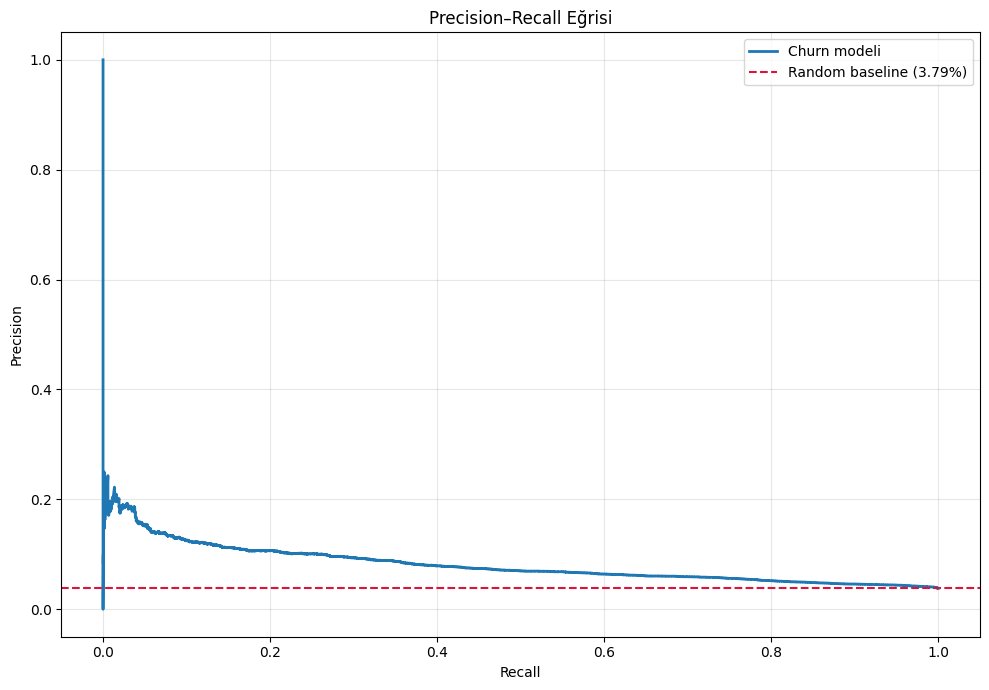

In [36]:
precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        test_scores,
    )
)

test_prevalence = y_test.mean()

plt.figure(figsize=(10, 7))

plt.plot(
    recall,
    precision,
    label="Churn modeli",
    linewidth=2,
)

plt.axhline(
    test_prevalence,
    color="crimson",
    linestyle="--",
    label=(
        f"Random baseline "
        f"({test_prevalence:.2%})"
    ),
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Eğrisi")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Calibration Grafiği**

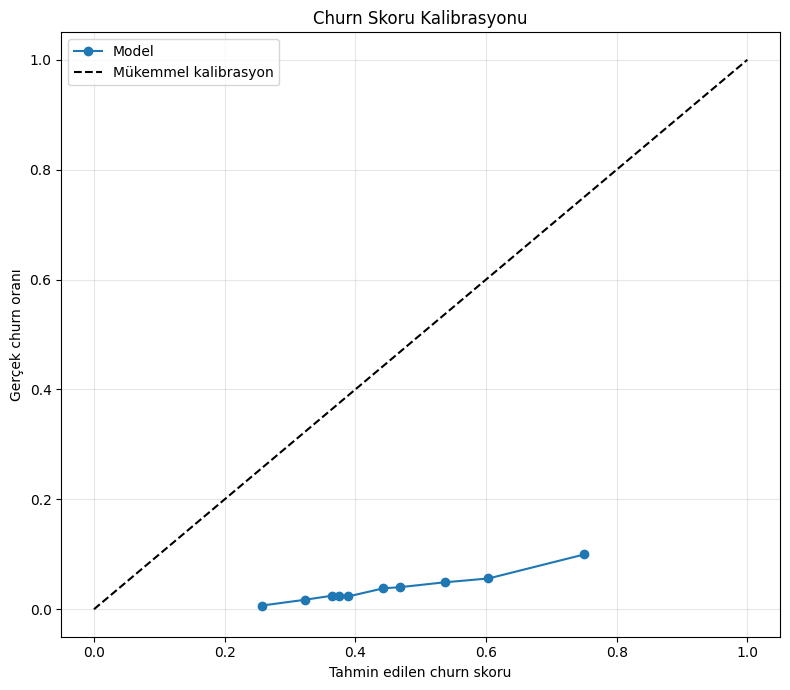

In [37]:
observed_rate, predicted_rate = (
    calibration_curve(
        y_test,
        test_scores,
        n_bins=10,
        strategy="quantile",
    )
)

plt.figure(figsize=(8, 7))

plt.plot(
    predicted_rate,
    observed_rate,
    marker="o",
    label="Model",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="black",
    label="Mükemmel kalibrasyon",
)

plt.xlabel("Tahmin edilen churn skoru")
plt.ylabel("Gerçek churn oranı")
plt.title("Churn Skoru Kalibrasyonu")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()